In [1]:
# Mount Drive -> find 'archive (3).zip' -> extract -> prepare '/content/mars-terrain-images'
from google.colab import drive
drive.mount('/content/drive')

import os, glob, zipfile, shutil

ZIP_NAME = 'archive (3).zip'                # your file name
EXTRACT_TMP = '/content/mars_zip_extract'   # temporary extract spot
TARGET_DIR = '/content/mars-terrain-images' # final dataset path
CLASS_HINTS = {'Craters','Rock','Sand_Dune','Plain','Other'}  # typical class dirs

# 1) Find the zip anywhere under Drive
candidates = glob.glob(f'/content/drive/**/{ZIP_NAME}', recursive=True)
if not candidates:
    raise FileNotFoundError(
        f"Could not find '{ZIP_NAME}' anywhere in Drive.\n"
        "Tip: verify the name (including spaces/parentheses) and re-run."
    )

zip_path = candidates[0]
print(f"Found ZIP at: {zip_path}")

# 2) Clean temp/existing dirs if needed
if os.path.exists(EXTRACT_TMP):
    shutil.rmtree(EXTRACT_TMP)
os.makedirs(EXTRACT_TMP, exist_ok=True)

if os.path.exists(TARGET_DIR):
    print(f"Removing existing target dir: {TARGET_DIR}")
    shutil.rmtree(TARGET_DIR)

# 3) Extract
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_TMP)
print(f"Extracted to: {EXTRACT_TMP}")

# 4) Find the folder that actually contains the class subfolders
def has_class_subdirs(path:str) -> bool:
    try:
        entries = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    except Exception:
        return False
    return len(CLASS_HINTS.intersection(set(entries))) >= 2  # at least two expected class dirs

# Candidate roots: the temp folder itself and all subdirectories
search_dirs = [EXTRACT_TMP]
for root, dirs, _ in os.walk(EXTRACT_TMP):
    for d in dirs:
        search_dirs.append(os.path.join(root, d))

dataset_root = None
for d in search_dirs:
    if has_class_subdirs(d):
        dataset_root = d
        break

if dataset_root is None:
    # Fallback: maybe the extracted zip *is* already the dataset folder level
    # In that case, just move everything and let the training script target it directly.
    print("Warning: Could not automatically detect class folders.\n"
          "Copying extracted tree as-is to TARGET_DIR; please verify structure.")
    shutil.copytree(EXTRACT_TMP, TARGET_DIR)
else:
    print(f"Detected dataset root with class folders: {dataset_root}")
    shutil.copytree(dataset_root, TARGET_DIR)

# 5) Show final structure
print(f"\nDataset prepared at: {TARGET_DIR}")
subdirs = [d for d in os.listdir(TARGET_DIR) if os.path.isdir(os.path.join(TARGET_DIR, d))]
print("Top-level subfolders:", subdirs)

# Quick sanity list a few files per class
for cls in sorted(set(subdirs).intersection(CLASS_HINTS)):
    cls_dir = os.path.join(TARGET_DIR, cls)
    samples = sorted(glob.glob(os.path.join(cls_dir, '*')))[:5]
    print(f"\n[{cls}] sample files:")
    for s in samples:
        print(" -", os.path.basename(s))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found ZIP at: /content/drive/MyDrive/archive (3).zip
Extracted to: /content/mars_zip_extract
Copying extracted tree as-is to TARGET_DIR; please verify structure.

Dataset prepared at: /content/mars-terrain-images
Top-level subfolders: ['Auburn_1']


In [4]:
# === Class counts + augmentation plan to reach 2,500 per class with 15 techniques ===
from pathlib import Path
import pandas as pd
import math

ROOT_DIR = Path('/content/mars-terrain-images/Auburn_1')
TARGET_PER_CLASS = 2500

# Define the 15 augmentation techniques (names only; implementation comes later)
AUG_TECHNIQUES = [
    "hflip",               # HorizontalFlip
    "vflip",               # VerticalFlip
    "rotate",              # Small random rotation
    "rand_resized_crop",   # RandomResizedCrop
    "brightness_contrast", # Random brightness/contrast
    "gamma",               # Random gamma
    "gaussian_noise",      # Additive Gaussian noise
    "gaussian_blur",       # Gaussian blur
    "motion_blur",         # Motion blur
    "sharpen",             # Sharpen
    "equalize",            # Histogram equalization (global or CLAHE)
    "perspective",         # Random perspective warp
    "affine_shear",        # Random shear/scale/translate
    "grid_distortion",     # GridDistortion / mild elastic
    "cutout",              # Random erasing / cutout
]

# 1) Count images per class
classes = [d.name for d in ROOT_DIR.iterdir() if d.is_dir()]
classes.sort()

def count_images(cls_dir: Path):
    exts = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff','.webp'}
    return sum(1 for p in cls_dir.rglob('*') if p.suffix.lower() in exts and p.is_file())

rows = []
for cls in classes:
    n = count_images(ROOT_DIR / cls)
    need = max(0, TARGET_PER_CLASS - n)
    rows.append({"class": cls, "current_count": n, "target": TARGET_PER_CLASS, "need_to_augment": need})

summary_df = pd.DataFrame(rows).sort_values("class").reset_index(drop=True)
summary_df


,class,current_count,target,need_to_augment
0,bright dune,591,2500,1909
1,crater,1056,2500,1444
2,dark dune,210,2500,2290
3,impact ejecta,45,2500,2455
4,other,3645,2500,0
5,slope streak,329,2500,2171
6,spider,60,2500,2440
7,swiss cheese,217,2500,2283


In [5]:
# 2) Distribute the needed augmentations evenly across 15 techniques (per class)
#    e.g., if need=103 -> each technique gets 6, and the first 13 techniques get +1 to cover remainder
def distribute_across_techniques(total_needed: int, techniques: list[str]) -> dict:
    if total_needed <= 0:
        return {t: 0 for t in techniques}
    base = total_needed // len(techniques)
    rem = total_needed % len(techniques)
    out = {t: base for t in techniques}
    # add one to the first 'rem' techniques
    for t in techniques[:rem]:
        out[t] += 1
    return out

# Build a long-form breakdown table: class | technique | aug_count
breakdown_rows = []
for _, r in summary_df.iterrows():
    alloc = distribute_across_techniques(int(r["need_to_augment"]), AUG_TECHNIQUES)
    for tech, cnt in alloc.items():
        breakdown_rows.append({"class": r["class"], "technique": tech, "aug_count": cnt})

breakdown_df = pd.DataFrame(breakdown_rows)
# Pivot for a wide view: rows=class, cols=technique, values=aug_count
pivot_df = breakdown_df.pivot(index="class", columns="technique", values="aug_count").fillna(0).astype(int)
pivot_df


technique,affine_shear,brightness_contrast,cutout,equalize,gamma,gaussian_blur,gaussian_noise,grid_distortion,hflip,motion_blur,perspective,rand_resized_crop,rotate,sharpen,vflip
class,,,,,,,,,,,,,,,
bright dune,127,127,127,127,127,127,127,127,128,127,127,128,128,127,128
crater,96,96,96,96,96,96,96,96,97,96,96,97,97,96,97
dark dune,152,153,152,152,153,153,153,152,153,153,152,153,153,153,153
impact ejecta,163,164,163,163,164,164,164,163,164,164,163,164,164,164,164
other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
slope streak,144,145,144,145,145,145,145,144,145,145,144,145,145,145,145
spider,162,163,162,162,163,163,163,162,163,163,162,163,163,163,163
swiss cheese,152,152,152,152,152,152,152,152,153,152,152,152,153,152,153


In [6]:
# === On-the-fly augmentation + class-balanced sampling (target ~2500 samples per class per epoch) ===
# Uses your existing dataset at /content/mars-terrain-images/Auburn_1
# - 15 augmentation techniques applied on-the-fly (no files written)
# - Balanced sampling so each epoch *sees* ~2500 samples per class (with replacement)
# - Rebuilds train_loader; val/test loaders remain the same as before

from pathlib import Path
import math, random
from collections import defaultdict, Counter

import torch
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np

# ----- CONFIG -----
SEED = 42
ROOT_DIR = Path('/content/mars-terrain-images/Auburn_1')
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
TARGET_PER_CLASS_PER_EPOCH = 2500  # effective seen samples per class, per epoch

random.seed(SEED)
torch.manual_seed(SEED)

# ----- CUSTOM SMALL TRANSFORMS (to reach the full set of 15) -----
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.05):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        if not torch.is_tensor(tensor):
            tensor = TF.to_tensor(tensor)
        noise = torch.randn_like(tensor) * self.std + self.mean
        out = tensor + noise
        return out.clamp(0.0, 1.0)

class AdjustGamma(object):
    def __init__(self, gamma_range=(0.7, 1.3)):
        self.gamma_range = gamma_range
    def __call__(self, img):
        g = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma=g)

# Helper to ensure RGB
to_rgb = transforms.Lambda(lambda img: img.convert('RGB'))

# ----- 15 AUGMENTATION TECHNIQUES (each with its own small probability) -----
aug_list = [
    transforms.RandomHorizontalFlip(p=0.5),             # 1
    transforms.RandomVerticalFlip(p=0.1),               # 2
    transforms.RandomRotation(degrees=15),              # 3
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),  # 4
    transforms.ColorJitter(brightness=0.25, contrast=0.25),    # 5
    AdjustGamma(gamma_range=(0.7, 1.3)),                # 6
    transforms.GaussianBlur(kernel_size=3),             # 7
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),  # 8
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),  # 9
    transforms.RandomAffine(degrees=0, shear=10),       # 10
    transforms.RandomAutocontrast(p=0.3),               # 11
    transforms.RandomEqualize(p=0.3),                   # 12
    transforms.RandomPosterize(bits=5, p=0.3),          # 13
    # Cutout/Random Erasing is applied AFTER ToTensor (below)           # 14 (post-tensor)
    # Additive Gaussian Noise is applied AFTER ToTensor (below)         # 15 (post-tensor)
]

# Compose train transforms:
# We first resize slightly bigger, then randomly apply a subset (by chaining with reasonable probs),
# then ToTensor/Normalize, then post-tensor augmentations (erasing + noise).
train_tfms = transforms.Compose([
    to_rgb,
    transforms.Resize(int(IMG_SIZE * 1.15)),
    # Chain the list (the individual transforms already have their own randomness/probabilities)
    *aug_list,
    transforms.CenterCrop(IMG_SIZE),  # ensure final size (in case of rotations/perspective)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), inplace=False),
    transforms.Lambda(lambda t: AddGaussianNoise(std=0.03)(t)),
])

# Eval transforms (no heavy aug)
eval_tfms = transforms.Compose([
    to_rgb,
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ----- DATASETS (same files, different transforms) -----
base_train = datasets.ImageFolder(root=str(ROOT_DIR), transform=train_tfms)
base_eval  = datasets.ImageFolder(root=str(ROOT_DIR), transform=eval_tfms)
class_names = base_train.classes
num_classes = len(class_names)
print("Classes:", class_names)

if len(base_train.samples) == 0:
    raise RuntimeError(f"No images found under {ROOT_DIR}. Expected class subfolders with images.")

# ----- STRATIFIED SPLIT (75/15/10) — same as before, in-memory -----
from collections import defaultdict
indices_by_class = defaultdict(list)
for idx, (_, y) in enumerate(base_train.samples):
    indices_by_class[y].append(idx)

train_idx, val_idx, test_idx = [], [], []
for cls_id, idxs in indices_by_class.items():
    random.shuffle(idxs)
    n = len(idxs)
    n_train = int(math.floor(0.75 * n))
    n_test  = int(math.floor(0.15 * n))
    n_val   = n - n_train - n_test
    if n >= 3:
        if n_test == 0 and n_val > 1:
            n_test, n_val = 1, n_val - 1
        if n_val == 0 and n_test > 1:
            n_val, n_test = 1, n_test - 1
    train_idx.extend(idxs[:n_train])
    test_idx.extend(idxs[n_train:n_train+n_test])
    val_idx.extend(idxs[n_train+n_test:])

train_ds = Subset(base_train, train_idx)
val_ds   = Subset(base_eval,  val_idx)
test_ds  = Subset(base_eval,  test_idx)

# ----- CLASS-BALANCED SAMPLER (approx 2500 per class per epoch) -----
# WeightedRandomSampler with replacement: weight per sample = 1 / count_of_class
# num_samples per epoch = TARGET_PER_CLASS_PER_EPOCH * num_classes
targets_train = [base_train.targets[i] for i in train_ds.indices]
class_counts = Counter(targets_train)
weights_per_class = {c: 1.0 / class_counts[c] for c in class_counts}
sample_weights = torch.DoubleTensor([weights_per_class[y] for y in targets_train])

num_samples_epoch = TARGET_PER_CLASS_PER_EPOCH * num_classes
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=num_samples_epoch,
                                replacement=True)

# ----- DATALOADERS -----
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ----- REPORT COUNTS + EFFECTIVE EPOCH SIZE -----
def split_counts(subset):
    targets = [base_train.targets[i] for i in subset.indices]
    cnt = Counter(targets)
    return {class_names[k]: cnt.get(k,0) for k in range(num_classes)}

print("\nUnderlying file counts per split (before oversampling):")
print("Train:", split_counts(train_ds))
print("Val  :", split_counts(val_ds))
print("Test :", split_counts(test_ds))

print(f"\nEach training epoch will draw ~{TARGET_PER_CLASS_PER_EPOCH} samples/class "
      f"= {num_samples_epoch} samples total (with replacement) through the sampler.")
print("Augmentations are applied on-the-fly, so each seen sample is stochastically different.")


Classes: ['bright dune', 'crater', 'dark dune', 'impact ejecta', 'other', 'slope streak', 'spider', 'swiss cheese']

Underlying file counts per split (before oversampling):
Train: {'bright dune': 443, 'crater': 792, 'dark dune': 157, 'impact ejecta': 33, 'other': 2733, 'slope streak': 246, 'spider': 45, 'swiss cheese': 162}
Val  : {'bright dune': 60, 'crater': 106, 'dark dune': 22, 'impact ejecta': 6, 'other': 366, 'slope streak': 34, 'spider': 6, 'swiss cheese': 23}
Test : {'bright dune': 88, 'crater': 158, 'dark dune': 31, 'impact ejecta': 6, 'other': 546, 'slope streak': 49, 'spider': 9, 'swiss cheese': 32}

Each training epoch will draw ~2500 samples/class = 20000 samples total (with replacement) through the sampler.
Augmentations are applied on-the-fly, so each seen sample is stochastically different.


In [7]:
# === Train ResNet-34 on the in-memory split ===
# Assumes you already ran the previous cell that created:
#   train_loader, val_loader, test_loader, class_names
# This will:
#   - build a ResNet-34 (ImageNet-pretrained)
#   - train for a few epochs with AMP
#   - report val accuracy each epoch (+ per-class at the end)
#   - save the best checkpoint to /content/best_resnet34_marsterrain.pth

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- CONFIG ----
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-4
AMP = True  # mixed precision
BEST_PATH = "/content/best_resnet34_marsterrain.pth"

# ---- MODEL ----
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(class_names))
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=AMP)

def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    if train:
        for xb, yb in tqdm(loader, desc="Train", leave=False):
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            preds = logits.argmax(1)
            running_loss += loss.item() * yb.size(0)
            running_correct += (preds == yb).sum().item()
            total += yb.size(0)
        return running_loss / max(total,1), running_correct / max(total,1)
    else:
        # eval
        cm = torch.zeros((len(class_names), len(class_names)), dtype=torch.int64, device="cpu")
        with torch.no_grad():
            for xb, yb in tqdm(loader, desc="Eval", leave=False):
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logits = model(xb)
                loss = criterion(logits, yb)

                preds = logits.argmax(1)
                running_loss += loss.item() * yb.size(0)
                running_correct += (preds == yb).sum().item()
                total += yb.size(0)

                for t, p in zip(yb.view(-1).cpu(), preds.view(-1).cpu()):
                    cm[t.long(), p.long()] += 1
        avg_loss = running_loss / max(total,1)
        acc = running_correct / max(total,1)
        return avg_loss, acc, cm

best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    print(f"  Train  | loss: {train_loss:.4f} | acc: {train_acc:.4f}")

    val_loss, val_acc, val_cm = run_epoch(model, val_loader, train=False)
    print(f"  Val    | loss: {val_loss:.4f} | acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_acc": best_val_acc,
            "class_names": class_names
        }, BEST_PATH)
        print(f"  ✅ Saved new best to {BEST_PATH} (val_acc={best_val_acc:.4f})")

# ---- Per-class accuracy on VAL ----
per_class_acc = val_cm.diag() / val_cm.sum(dim=1).clamp(min=1)
print("\nPer-class accuracy (VAL):")
for i, cls in enumerate(class_names):
    print(f"  {cls:>12s}: {float(per_class_acc[i]):.4f}")

# ---- Optional: evaluate on TEST once at the end ----
test_loss, test_acc, test_cm = run_epoch(model, test_loader, train=False)
print(f"\nTEST | loss: {test_loss:.4f} | acc: {test_acc:.4f}")


Device: cuda


/tmp/ipython-input-2257322357.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)



Epoch 1/10


Train:   0%|          | 0/313 [00:00<?, ?it/s]/tmp/ipython-input-2257322357.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):


  Train  | loss: 0.5868 | acc: 0.7981


...

  Train  | loss: 0.2167 | acc: 0.9265


  Val    | loss: 2.0023 | acc: 0.5891

Epoch 10/10


  Train  | loss: 0.2042 | acc: 0.9307


  Val    | loss: 1.3157 | acc: 0.7063

Per-class accuracy (VAL):
   bright dune: 0.9667
        crater: 0.7075
     dark dune: 0.4091
  impact ejecta: 0.3333
         other: 0.6612
  slope streak: 0.7353
        spider: 1.0000
  swiss cheese: 1.0000



TEST | loss: 1.1636 | acc: 0.7301


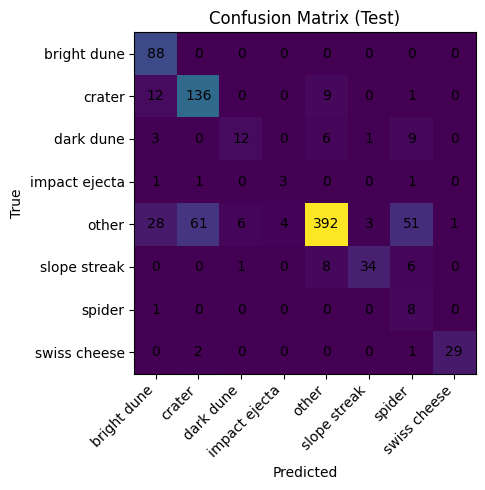

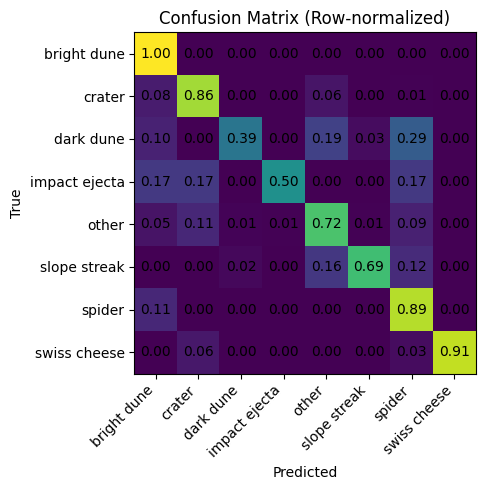

In [8]:
# --- Confusion Matrix on TEST ---
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model and load best weights (path must match your training cell)
BEST_PATH = "/content/best_resnet34_marsterrain.pth"
ckpt = torch.load(BEST_PATH, map_location=device)
num_classes = len(class_names)

model = models.resnet34(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device)
model.eval()

# Compute confusion matrix on test
cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(1)
        for t, p in zip(yb.view(-1), preds.view(-1)):
            cm[t.long(), p.long()] += 1

# Plot raw CM
plt.figure(figsize=(6, 5))
plt.imshow(cm.cpu().numpy(), interpolation='nearest')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')
plt.tight_layout()
plt.show()

# Plot row-normalized CM
cm_row = cm.float() / cm.sum(dim=1, keepdim=True).clamp(min=1)
plt.figure(figsize=(6, 5))
plt.imshow(cm_row.cpu().numpy(), interpolation='nearest')
plt.title("Confusion Matrix (Row-normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        val = cm_row[i, j].item()
        plt.text(j, i, f"{val:.2f}", ha='center', va='center')
plt.tight_layout()
plt.show()


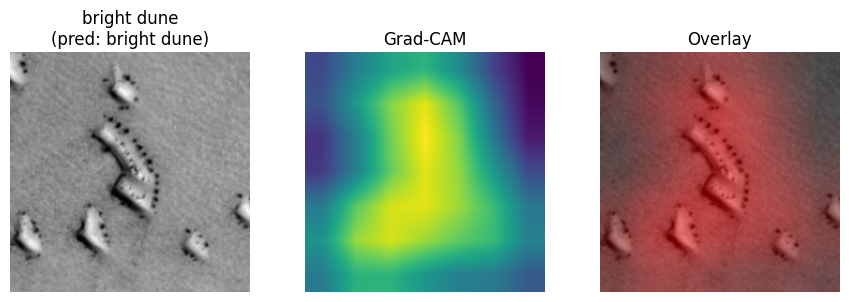

Saved: /content/gradcam_per_class/gradcam_bright dune.png


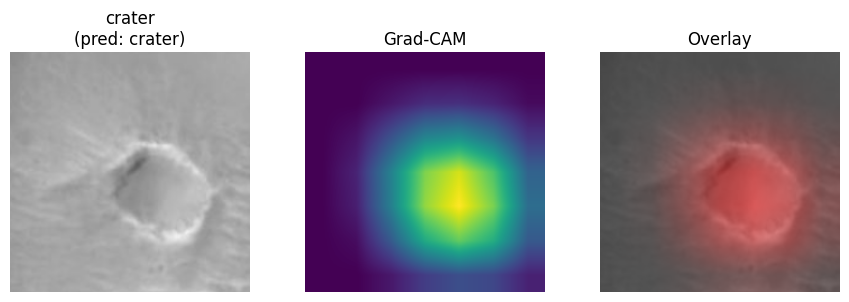

Saved: /content/gradcam_per_class/gradcam_crater.png


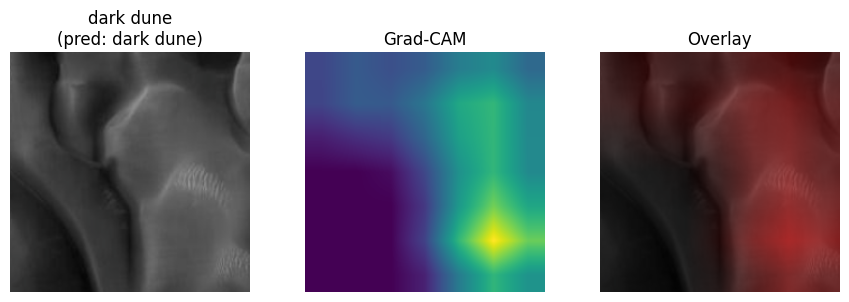

Saved: /content/gradcam_per_class/gradcam_dark dune.png


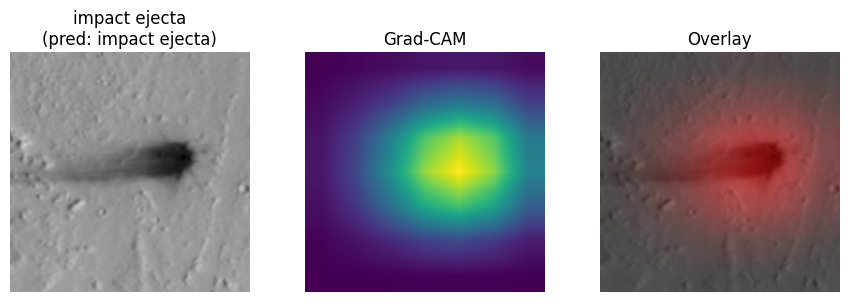

Saved: /content/gradcam_per_class/gradcam_impact ejecta.png


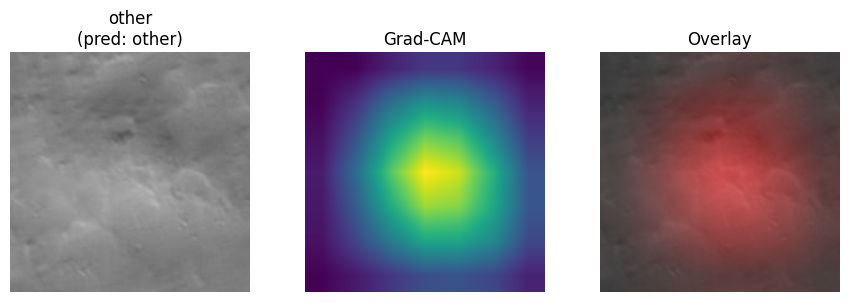

Saved: /content/gradcam_per_class/gradcam_other.png


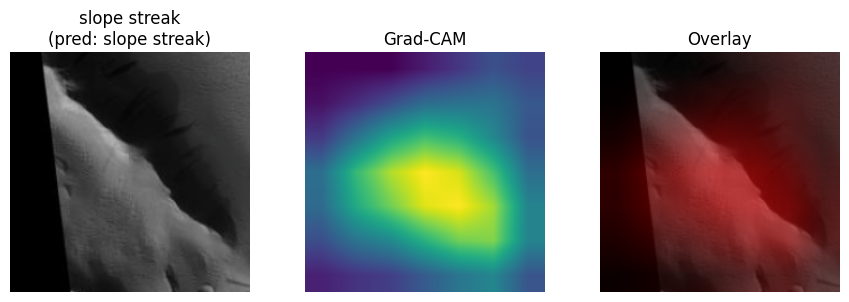

Saved: /content/gradcam_per_class/gradcam_slope streak.png


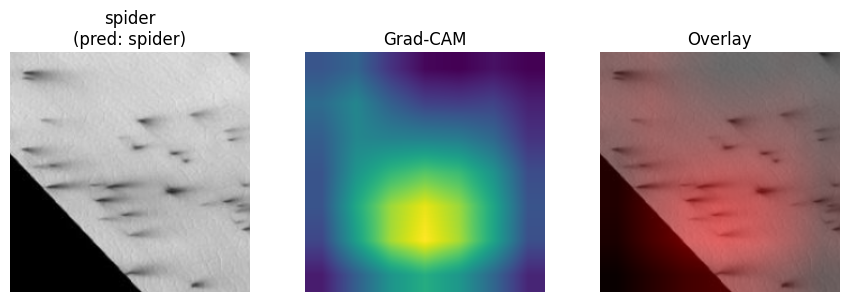

Saved: /content/gradcam_per_class/gradcam_spider.png


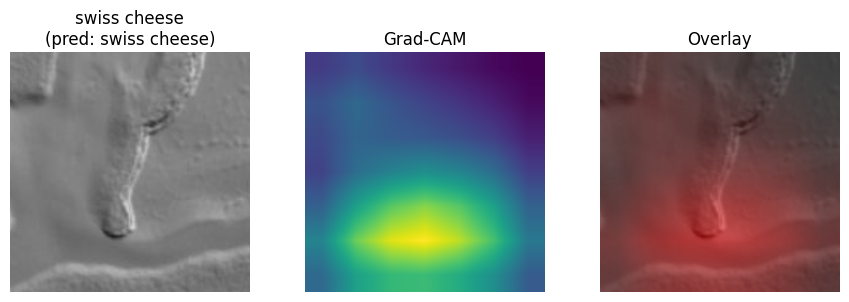

Saved: /content/gradcam_per_class/gradcam_swiss cheese.png


In [10]:
# === Grad-CAM: one correctly classified example per class ===
import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/content/gradcam_per_class"
os.makedirs(SAVE_DIR, exist_ok=True)

# Try to reuse model; otherwise load best checkpoint
try:
    _ = model  # noqa
except NameError:
    BEST_PATH = "/content/best_resnet34_marsterrain.pth"
    ckpt = torch.load(BEST_PATH, map_location=device)
    num_classes = len(class_names)
    model = models.resnet34(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(device)
model.eval()

# Helper to unnormalize image for display
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
def to_numpy_img(t):
    x = t * IMAGENET_STD + IMAGENET_MEAN
    x = x.clamp(0, 1)
    x = x[0].permute(1,2,0).detach().cpu().numpy()
    return x

# Hook last conv in layer4
target_conv = model.layer4[-1].conv2
feats, grads = [], []
def fwd_hook(m, inp, out): feats.append(out.detach())
def bwd_hook(m, gin, gout): grads.append(gout[0].detach())
fwd_handle = target_conv.register_forward_hook(fwd_hook)
bwd_handle = target_conv.register_full_backward_hook(bwd_hook)

# Find one correctly classified sample per class
needed = set(range(len(class_names)))
picked_by_class = {}  # cls_id -> (img[1,3,H,W], true_id, pred_id)

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(1)
        correct_mask = preds.eq(yb)
        if correct_mask.any():
            for i in correct_mask.nonzero(as_tuple=False).flatten().tolist():
                c = int(yb[i].item())
                if c in needed:
                    picked_by_class[c] = (xb[i:i+1].clone(), c, int(preds[i].item()))
                    needed.discard(c)
        if not needed:
            break

if needed:
    print(f"Warning: Could not find correctly classified samples for classes: {[class_names[i] for i in sorted(needed)]}")

# Generate Grad-CAM for each picked class
for cls_id, (x1, y_true, y_pred) in picked_by_class.items():
    # Forward + backward for the predicted class
    feats.clear(); grads.clear()
    out = model(x1)
    score = out[0, y_pred]
    model.zero_grad(set_to_none=True)
    score.backward()

    # CAM
    feat = feats[-1]                      # [1,C,h,w]
    grad = grads[-1]                      # [1,C,h,w]
    weights = grad.mean(dim=(2,3), keepdim=True)       # [1,C,1,1]
    cam = (weights * feat).sum(dim=1, keepdim=True)    # [1,1,h,w]
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=x1.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam_np = cam[0,0].detach().cpu().numpy()

    # Visualize & save
    orig = to_numpy_img(x1.clone())

    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.axis('off'); plt.title(f"{class_names[y_true]}\n(pred: {class_names[y_pred]})")
    plt.imshow(orig)
    plt.subplot(1,3,2); plt.axis('off'); plt.title("Grad-CAM")
    plt.imshow(cam_np, alpha=1.0)
    plt.subplot(1,3,3); plt.axis('off'); plt.title("Overlay")
    overlay = (orig*0.5 + np.stack([cam_np, np.zeros_like(cam_np), np.zeros_like(cam_np)], axis=2)*0.5)
    overlay = np.clip(overlay, 0, 1)
    plt.imshow(overlay)
    plt.tight_layout()

    out_path = os.path.join(SAVE_DIR, f"gradcam_{class_names[cls_id]}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

# Cleanup hooks
fwd_handle.remove(); bwd_handle.remove()
